# Shamil: Stock Market Data Mining
### AAPL · TSLA · AMZN | March 2025 – March 2026

This notebook covers:
1. Loading and previewing collected stock data and the Reddit-stock integration dataset
2. Visualizing price trends, volatility, and moving averages
3. Plotting Reddit sentiment against stock prices
4. Computing **Pearson** and **Spearman** correlation coefficients between sentiment features and stock metrics
5. Analyzing the **next-week price change lag** to detect if Reddit activity precedes price moves

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="darkgrid", palette="tab10")
plt.rcParams["figure.dpi"] = 110

BASE = r"c:\Users\shami\Documents\team project semester 4"
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load and Preview Stock Data
Daily closing prices, volume, daily return, MA7 and MA30 for AAPL, TSLA, and AMZN.

In [2]:
stock = pd.read_csv(f"{BASE}\\stock_data_final.csv", parse_dates=["date"])

print(f"Shape: {stock.shape}")
print(f"\nData types:\n{stock.dtypes}")
print(f"\nDate range: {stock['date'].min().date()} → {stock['date'].max().date()}")
print(f"\nTickers: {sorted(stock['ticker'].unique())}")
print(f"\nRows per ticker:\n{stock['ticker'].value_counts()}")
stock.head(6)

Shape: (840, 7)

Data types:
date            datetime64[ns]
ticker                  object
close                  float64
volume                   int64
daily_return           float64
MA7                    float64
MA30                   float64
dtype: object

Date range: 2025-03-03 → 2026-03-27

Tickers: ['AAPL', 'AMZN', 'TSLA']

Rows per ticker:
ticker
AAPL    280
AMZN    280
TSLA    280
Name: count, dtype: int64


,date,ticker,close,volume,daily_return,MA7,MA30
0,2025-03-03,AAPL,236.9971,47184000,NaN,236.9971,236.9971
1,2025-03-04,AAPL,234.9062,53798100,-0.0088,235.9516,235.9516
2,2025-03-05,AAPL,234.7170,47227600,-0.0008,235.5401,235.5401
3,2025-03-06,AAPL,234.3088,45170400,-0.0017,235.2323,235.2323
4,2025-03-07,AAPL,238.0326,46273600,0.0159,235.7923,235.7923
5,2025-03-10,AAPL,226.4928,72071200,-0.0485,234.2424,234.2424


## 3. Load and Preview Correlation Dataset
Combined dataset merging weekly stock metrics with Percival's Reddit sentiment data.  
Join keys used: `year_week` + `ticker`.

In [3]:
corr_df = pd.read_csv(f"{BASE}\\correlation_dataset.csv")

print(f"Shape: {corr_df.shape}")
print(f"\nColumns:\n{list(corr_df.columns)}")
print(f"\nMissing values per column:")
missing = corr_df.isnull().sum()
print(missing[missing > 0])
corr_df.head(6)

Shape: (168, 19)

Columns:
['ticker', 'year_week', 'week_open_close', 'week_close', 'weekly_price_change_pct', 'next_week_price_change_pct', 'avg_volume', 'avg_daily_return', 'weekly_volatility', 'trading_days', 'post_count', 'avg_score', 'avg_upvote_ratio', 'avg_comments', 'avg_sentiment', 'positive_posts', 'negative_posts', 'neutral_posts', 'high_reddit_activity']

Missing values per column:
next_week_price_change_pct     3
post_count                    62
avg_score                     62
avg_upvote_ratio              62
avg_comments                  62
avg_sentiment                 62
positive_posts                62
negative_posts                62
neutral_posts                 62
dtype: int64


,ticker,year_week,week_open_close,week_close,weekly_price_change_pct,next_week_price_change_pct,avg_volume,avg_daily_return,weekly_volatility,trading_days,post_count,avg_score,avg_upvote_ratio,avg_comments,avg_sentiment,positive_posts,negative_posts,neutral_posts,high_reddit_activity
0,AAPL,2025-W10,236.9971,238.0326,0.4369,-6.1500,47930740,0.0011,0.0105,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,AAPL,2025-W11,226.4928,212.5636,-6.1500,1.9953,66446400,-0.0221,0.0251,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,AAPL,2025-W12,213.0714,217.3228,1.9953,-1.2821,57576380,0.0045,0.0111,5,2.0000,10932.0000,0.9700,431.0000,0.0000,0.0000,0.0000,2.0000,True
3,AAPL,2025-W13,219.7722,216.9544,-1.2821,-15.1938,38034520,-0.0002,0.0175,5,5.0000,10337.0000,0.9580,1237.0000,0.1320,2.0000,0.0000,3.0000,True
4,AAPL,2025-W14,221.1661,187.5625,-15.1938,9.1976,73389560,-0.0276,0.0511,5,7.0000,16239.8571,0.9314,1030.8571,-0.0309,2.0000,2.0000,3.0000,True
5,AAPL,2025-W15,180.6726,197.2901,9.1976,-2.7355,135007520,0.0130,0.0865,5,1.0000,1145.0000,0.9900,38.0000,0.0000,0.0000,0.0000,1.0000,False


## 4. Visualize Stock Price Trends
Closing price over time for each ticker.

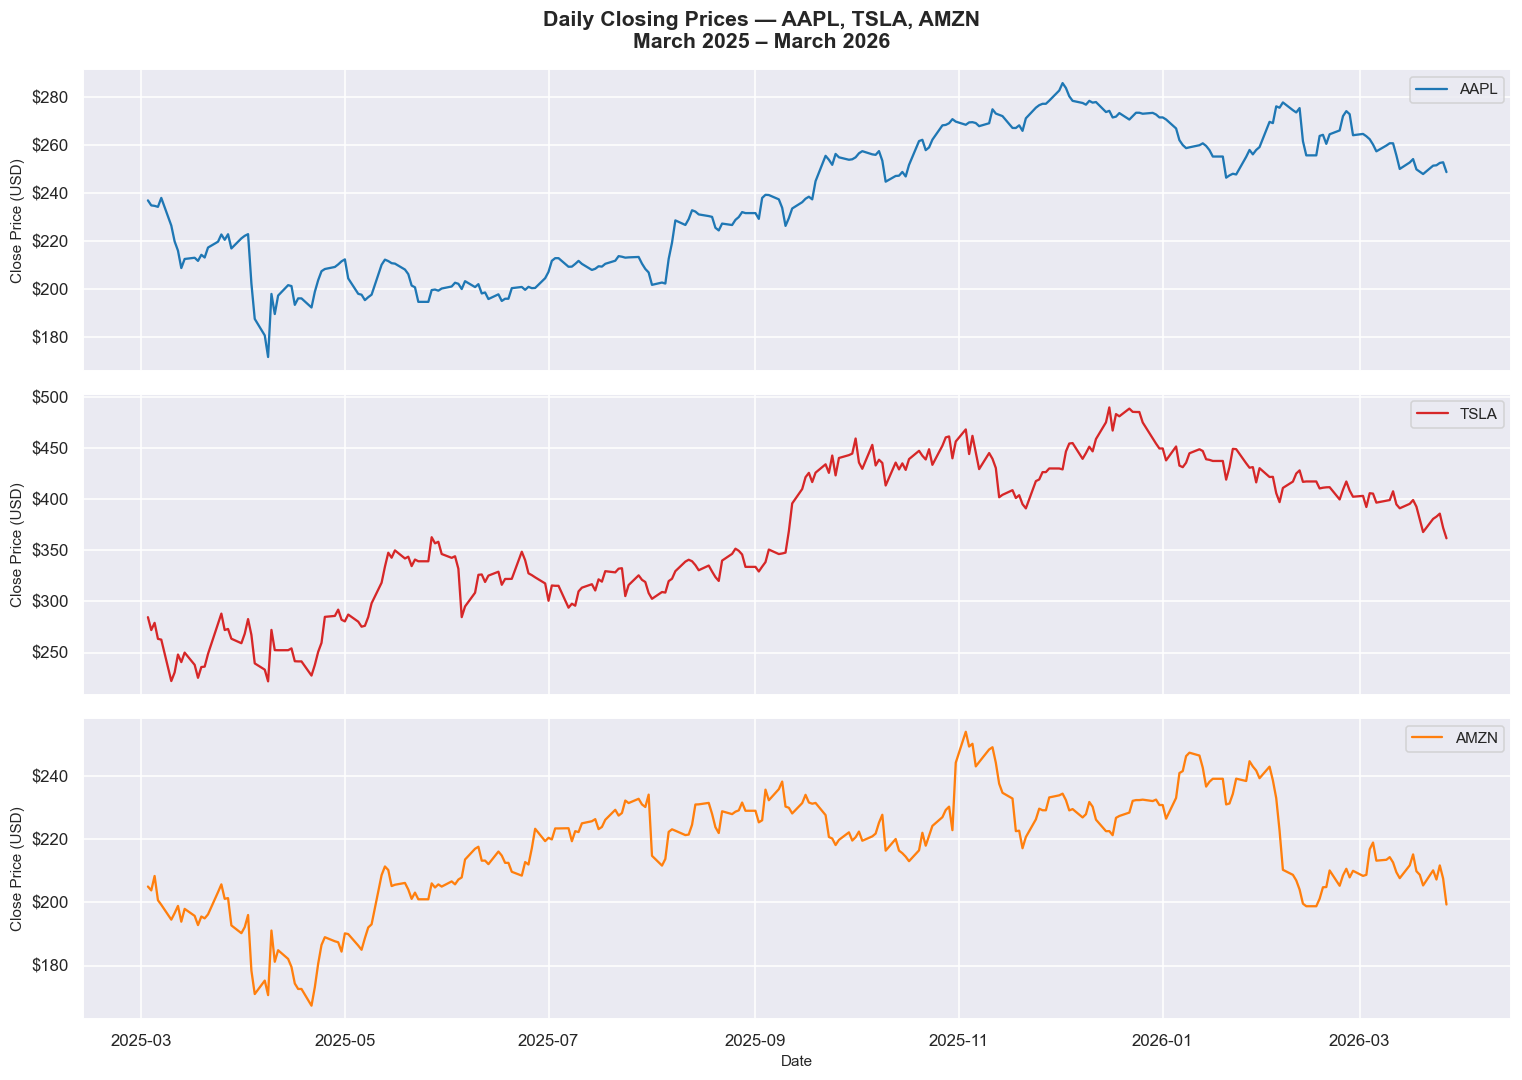

Saved → viz_price_trends.png


In [4]:
tickers = ["AAPL", "TSLA", "AMZN"]
colors  = {"AAPL": "#1f77b4", "TSLA": "#d62728", "AMZN": "#ff7f0e"}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Daily Closing Prices — AAPL, TSLA, AMZN\nMarch 2025 – March 2026", fontsize=14, fontweight="bold")

for ax, ticker in zip(axes, tickers):
    data = stock[stock["ticker"] == ticker]
    ax.plot(data["date"], data["close"], color=colors[ticker], linewidth=1.5, label=ticker)
    ax.set_ylabel("Close Price (USD)", fontsize=10)
    ax.legend(loc="upper right", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))

axes[-1].set_xlabel("Date", fontsize=10)
plt.tight_layout()
plt.savefig(f"{BASE}\\viz_price_trends.png", bbox_inches="tight")
plt.show()
print("Saved → viz_price_trends.png")

## 5. Volatility Analysis Visualization
Rolling 20-day standard deviation of daily returns — highlights high and low volatility periods.

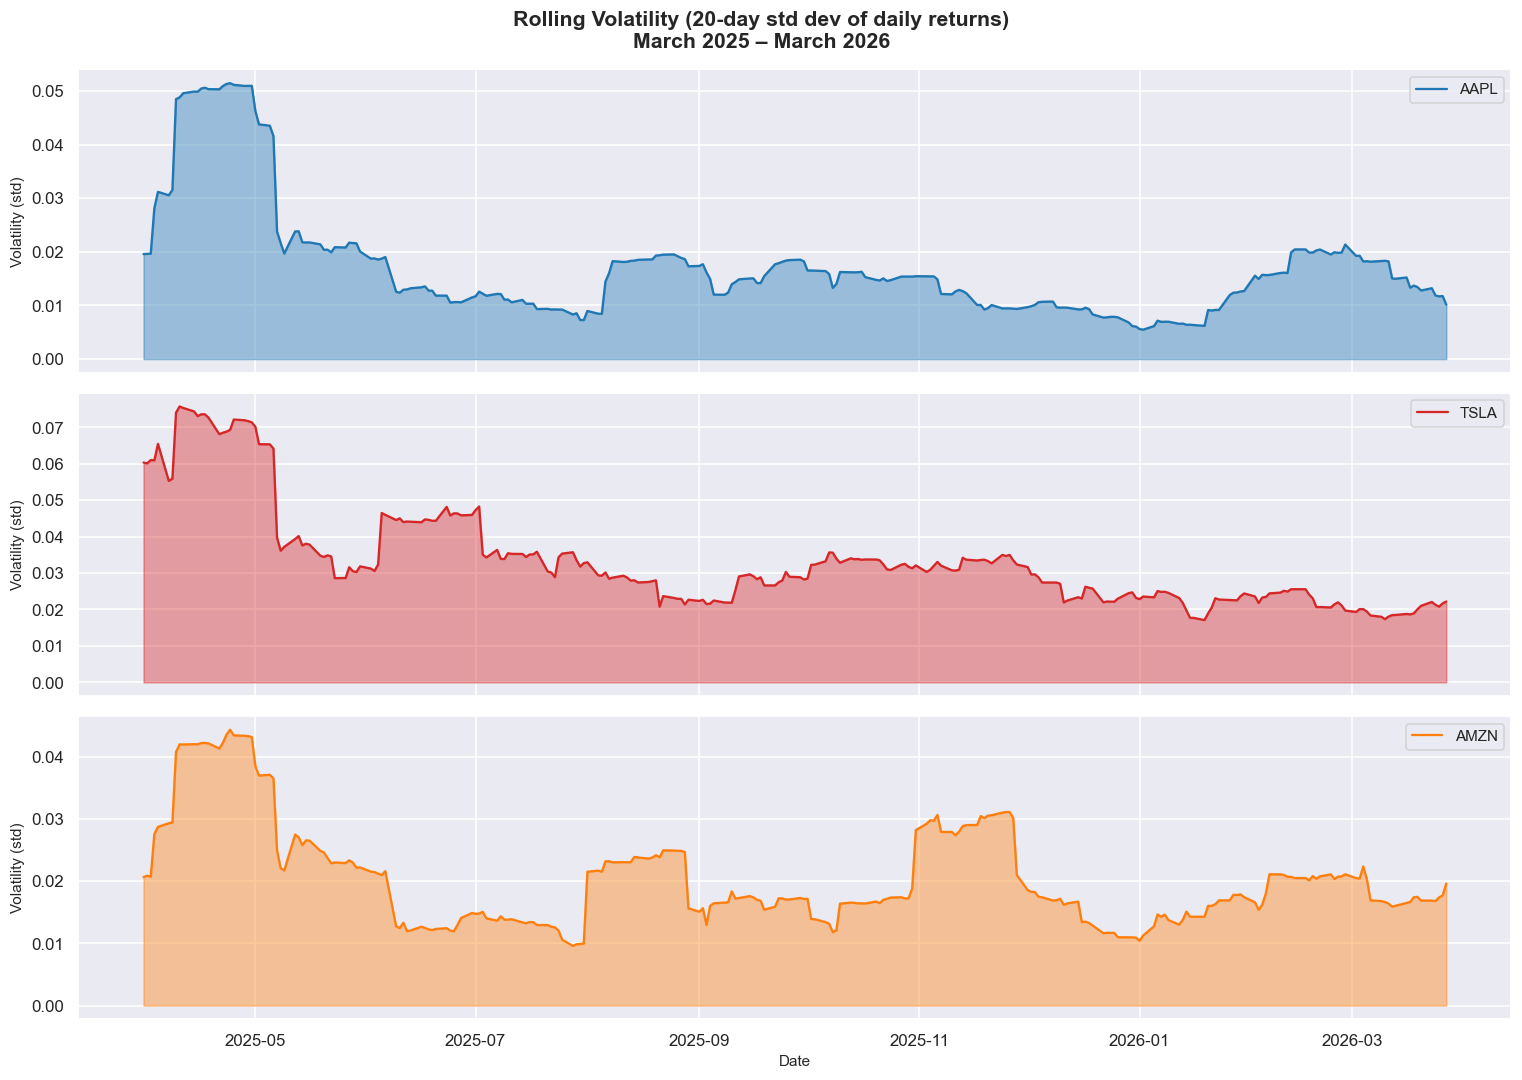

Saved → viz_volatility.png


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Rolling Volatility (20-day std dev of daily returns)\nMarch 2025 – March 2026", fontsize=14, fontweight="bold")

for ax, ticker in zip(axes, tickers):
    data = stock[stock["ticker"] == ticker].copy().sort_values("date")
    data["rolling_vol"] = data["daily_return"].rolling(window=20).std()
    ax.fill_between(data["date"], data["rolling_vol"], alpha=0.4, color=colors[ticker])
    ax.plot(data["date"], data["rolling_vol"], color=colors[ticker], linewidth=1.5, label=ticker)
    ax.set_ylabel("Volatility (std)", fontsize=10)
    ax.legend(loc="upper right", fontsize=10)

axes[-1].set_xlabel("Date", fontsize=10)
plt.tight_layout()
plt.savefig(f"{BASE}\\viz_volatility.png", bbox_inches="tight")
plt.show()
print("Saved → viz_volatility.png")

## 6. Moving Averages Visualization
7-day (short-term) and 30-day (baseline trend) moving averages alongside closing prices.

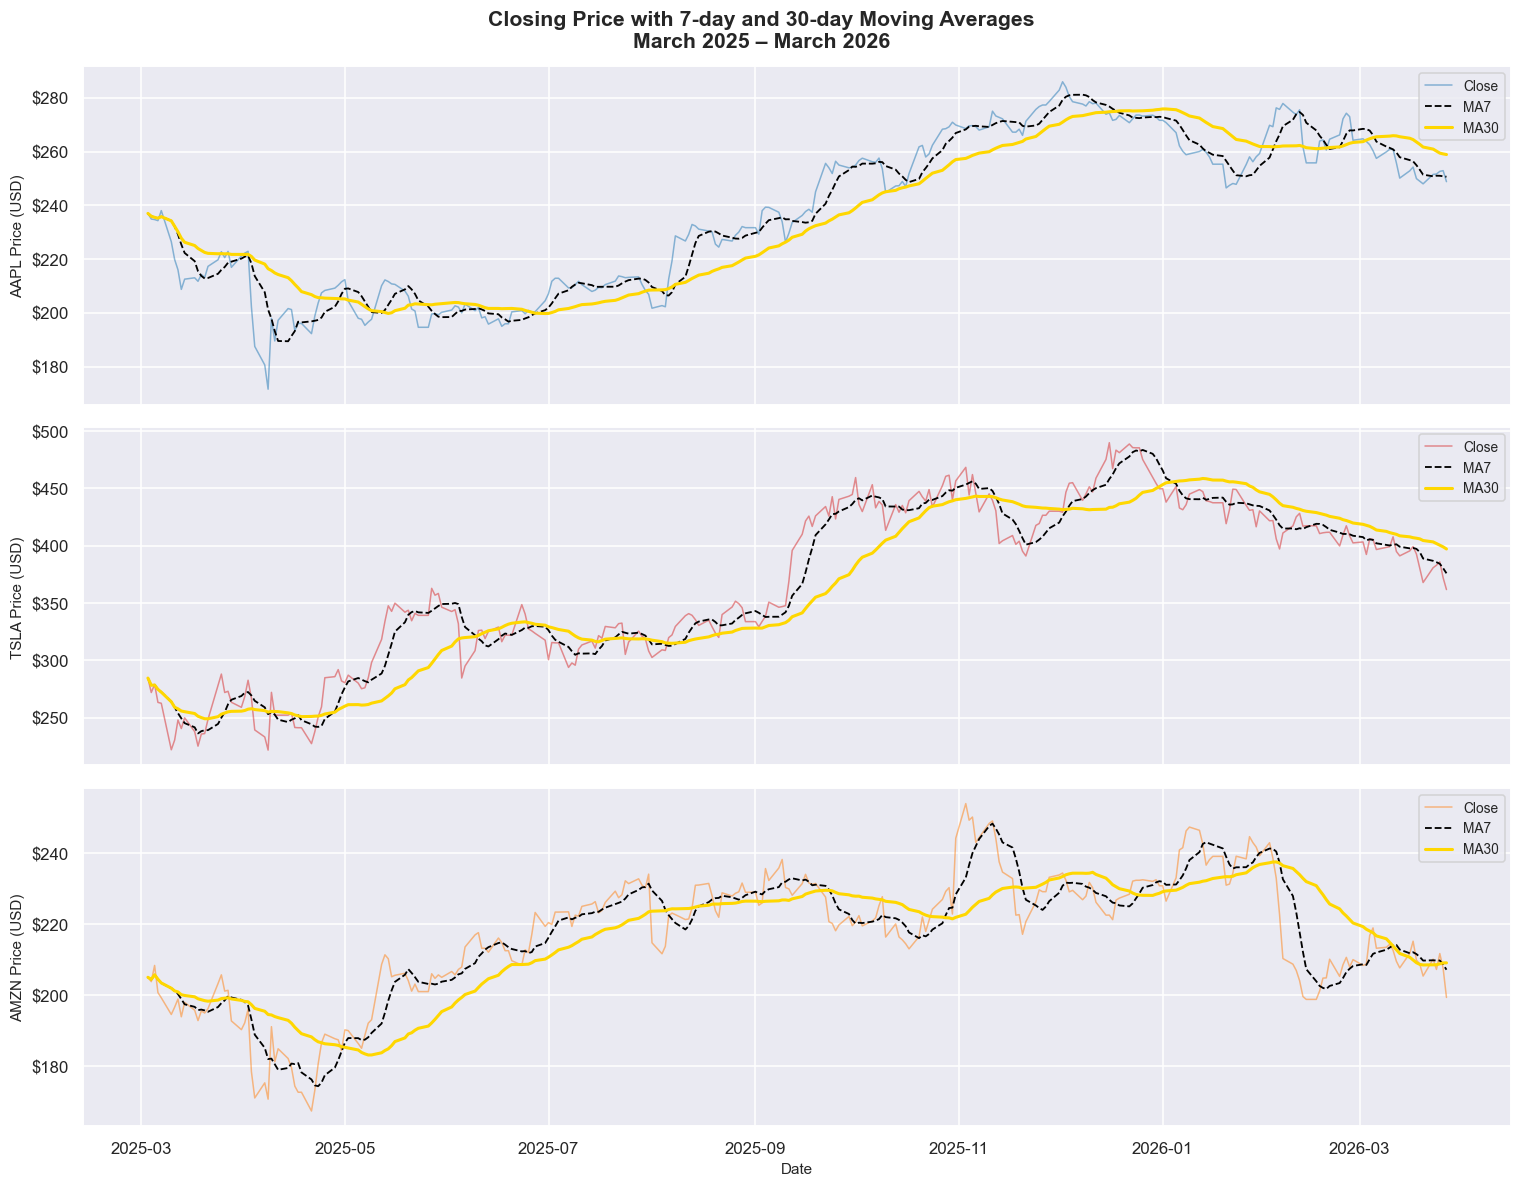

Saved → viz_moving_averages.png


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle("Closing Price with 7-day and 30-day Moving Averages\nMarch 2025 – March 2026", fontsize=14, fontweight="bold")

for ax, ticker in zip(axes, tickers):
    data = stock[stock["ticker"] == ticker].sort_values("date")
    ax.plot(data["date"], data["close"], color=colors[ticker], linewidth=1,   alpha=0.5, label="Close")
    ax.plot(data["date"], data["MA7"],   color="black",         linewidth=1.2, linestyle="--", label="MA7")
    ax.plot(data["date"], data["MA30"],  color="gold",          linewidth=2,   label="MA30")
    ax.set_ylabel(f"{ticker} Price (USD)", fontsize=10)
    ax.legend(loc="upper right", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))

axes[-1].set_xlabel("Date", fontsize=10)
plt.tight_layout()
plt.savefig(f"{BASE}\\viz_moving_averages.png", bbox_inches="tight")
plt.show()
print("Saved → viz_moving_averages.png")

## 7. Reddit Sentiment vs. Stock Price
Dual-axis charts comparing Reddit average score with the weekly closing price.  
Only weeks where Reddit data is available are plotted.

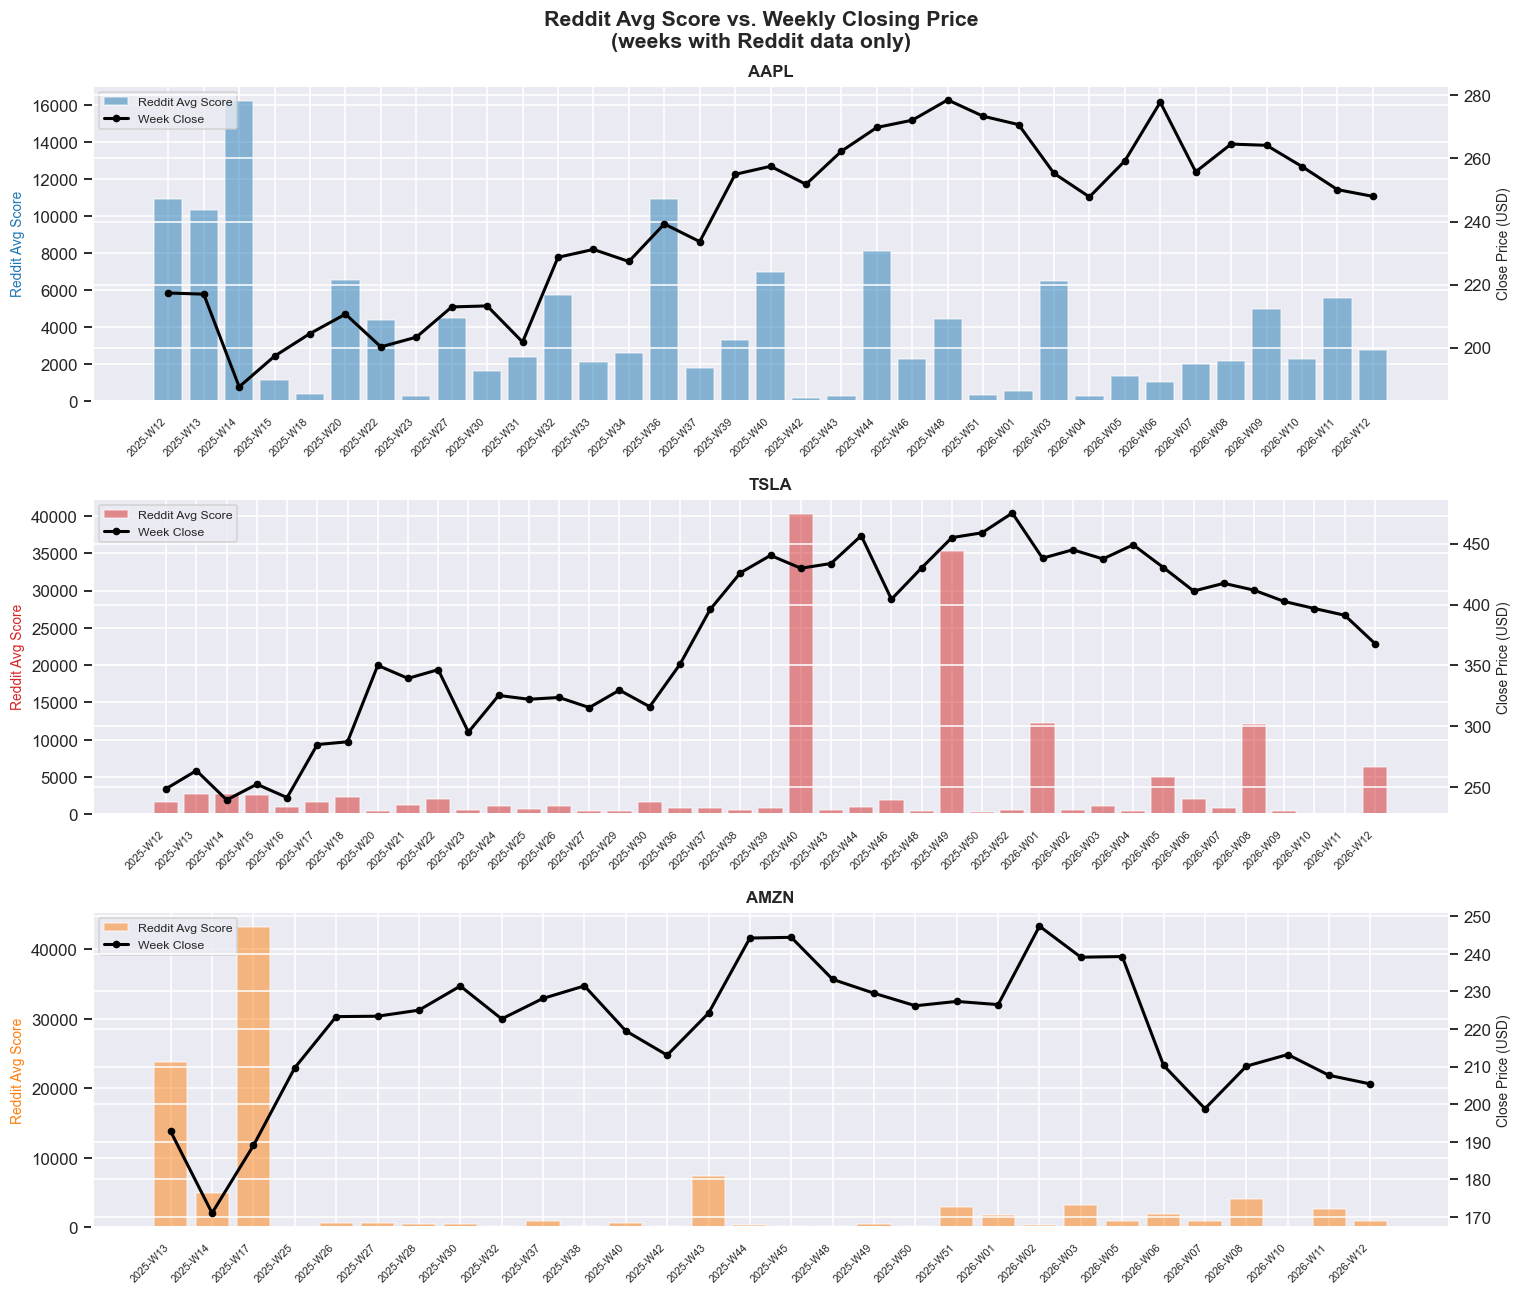

Saved → viz_reddit_vs_price.png


In [7]:
reddit_rows = corr_df[corr_df["avg_score"].notna()].copy()
reddit_rows = reddit_rows.sort_values(["ticker", "year_week"])

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)
fig.suptitle("Reddit Avg Score vs. Weekly Closing Price\n(weeks with Reddit data only)", fontsize=14, fontweight="bold")

for ax, ticker in zip(axes, tickers):
    data = reddit_rows[reddit_rows["ticker"] == ticker].reset_index(drop=True)
    x    = range(len(data))
    ax2  = ax.twinx()
    ax.bar(x, data["avg_score"], color=colors[ticker], alpha=0.5, label="Reddit Avg Score")
    ax2.plot(x, data["week_close"], color="black", linewidth=2, marker="o", markersize=4, label="Week Close")
    ax.set_xticks(list(x))
    ax.set_xticklabels(list(data["year_week"]), rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Reddit Avg Score", fontsize=9, color=colors[ticker])
    ax2.set_ylabel("Close Price (USD)", fontsize=9)
    ax.set_title(ticker, fontsize=11, fontweight="bold")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig(f"{BASE}\\viz_reddit_vs_price.png", bbox_inches="tight")
plt.show()
print("Saved → viz_reddit_vs_price.png")

## 8. Pearson Correlation Analysis
Pearson measures **linear** relationships between Reddit sentiment features and stock metrics.  
Only rows where Reddit data is present are used.

Pearson Correlation Matrix:
                  weekly_price_change_pct  next_week_price_change_pct  weekly_volatility  avg_daily_return  avg_volume
post_count                        -0.1348                     -0.0977             0.0667           -0.0696     -0.0085
avg_score                          0.0435                     -0.0727             0.0212            0.0004     -0.0422
avg_upvote_ratio                   0.0789                     -0.0070             0.0680            0.0197      0.0774
avg_comments                       0.0472                     -0.0318             0.0074            0.0301      0.0235
avg_sentiment                      0.0394                      0.0224            -0.1015            0.0500     -0.0366
positive_posts                     0.0009                     -0.0279            -0.0206            0.0133     -0.0449
negative_posts                    -0.1017                     -0.1519             0.2871           -0.0028      0.2121
neutral_posts       

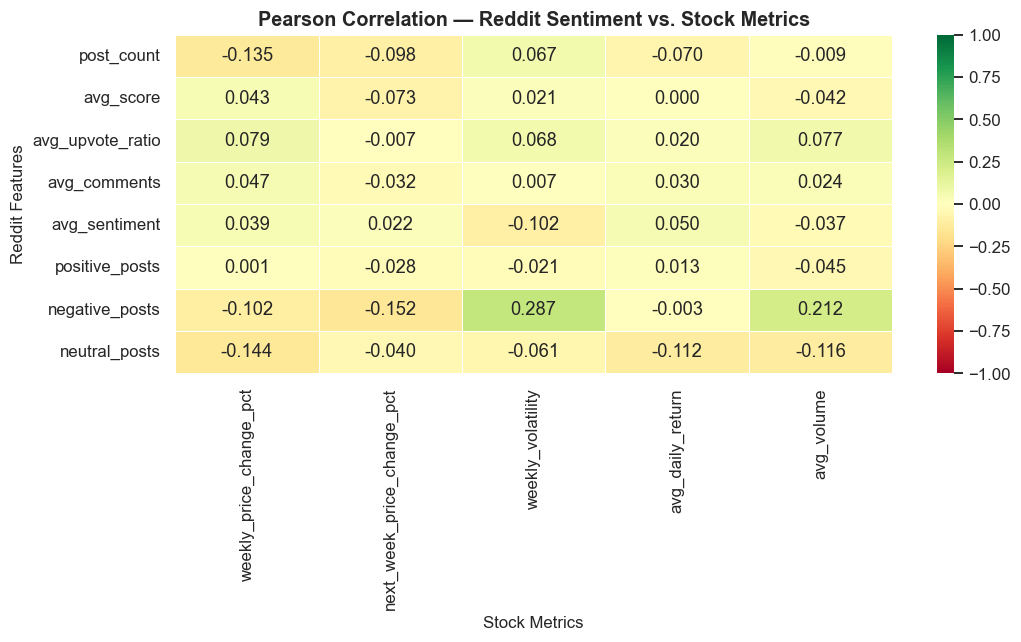

Saved → viz_pearson_heatmap.png


In [8]:
sentiment_features = [
    "post_count", "avg_score", "avg_upvote_ratio",
    "avg_comments", "avg_sentiment", "positive_posts",
    "negative_posts", "neutral_posts"
]
stock_metrics = [
    "weekly_price_change_pct", "next_week_price_change_pct",
    "weekly_volatility", "avg_daily_return", "avg_volume"
]

reddit_only = corr_df[corr_df["avg_score"].notna()][sentiment_features + stock_metrics].copy()

pearson_matrix = pd.DataFrame(index=sentiment_features, columns=stock_metrics, dtype=float)
for sf in sentiment_features:
    for sm in stock_metrics:
        valid = reddit_only[[sf, sm]].dropna()
        if len(valid) > 4:
            r, _ = stats.pearsonr(valid[sf], valid[sm])
            pearson_matrix.loc[sf, sm] = round(r, 4)

print("Pearson Correlation Matrix:")
print(pearson_matrix.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pearson_matrix.astype(float),
    annot=True, fmt=".3f", cmap="RdYlGn",
    center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1
)
ax.set_title("Pearson Correlation — Reddit Sentiment vs. Stock Metrics", fontsize=13, fontweight="bold")
ax.set_xlabel("Stock Metrics", fontsize=11)
ax.set_ylabel("Reddit Features", fontsize=11)
plt.tight_layout()
plt.savefig(f"{BASE}\\viz_pearson_heatmap.png", bbox_inches="tight")
plt.show()
print("Saved → viz_pearson_heatmap.png")

## 9. Spearman Correlation Analysis
Spearman measures **rank-based (non-linear)** relationships — more robust to outliers and skewed distributions.

Spearman Correlation Matrix:
                  weekly_price_change_pct  next_week_price_change_pct  weekly_volatility  avg_daily_return  avg_volume
post_count                        -0.1391                     -0.0642            -0.0092           -0.0257     -0.0219
avg_score                         -0.1029                     -0.0250            -0.0252           -0.1017      0.0235
avg_upvote_ratio                   0.0491                     -0.0394            -0.0619           -0.0805      0.0140
avg_comments                      -0.1176                      0.0120             0.0949           -0.0433      0.1197
avg_sentiment                     -0.0134                      0.0413            -0.0495           -0.0436     -0.0733
positive_posts                    -0.1155                     -0.0739             0.0509           -0.0474     -0.0316
negative_posts                     0.0074                     -0.1228             0.1300            0.1140      0.0860
neutral_posts      

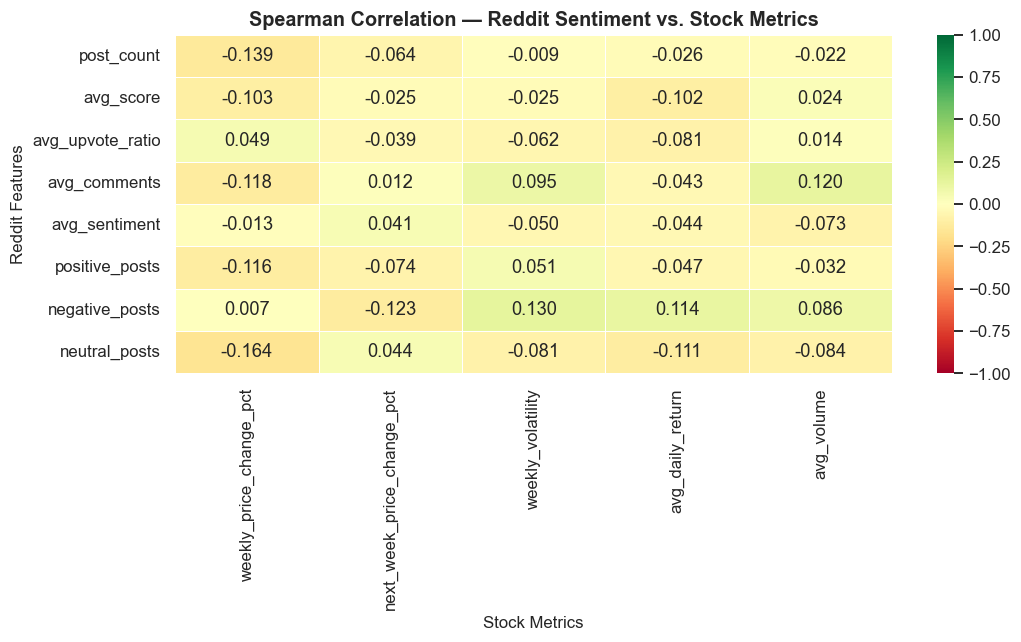

Saved → viz_spearman_heatmap.png


In [9]:
spearman_matrix = pd.DataFrame(index=sentiment_features, columns=stock_metrics, dtype=float)
spearman_pval   = pd.DataFrame(index=sentiment_features, columns=stock_metrics, dtype=float)

for sf in sentiment_features:
    for sm in stock_metrics:
        valid = reddit_only[[sf, sm]].dropna()
        if len(valid) > 4:
            r, p = stats.spearmanr(valid[sf], valid[sm])
            spearman_matrix.loc[sf, sm] = round(r, 4)
            spearman_pval.loc[sf, sm]   = round(p, 4)

print("Spearman Correlation Matrix:")
print(spearman_matrix.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    spearman_matrix.astype(float),
    annot=True, fmt=".3f", cmap="RdYlGn",
    center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1
)
ax.set_title("Spearman Correlation — Reddit Sentiment vs. Stock Metrics", fontsize=13, fontweight="bold")
ax.set_xlabel("Stock Metrics", fontsize=11)
ax.set_ylabel("Reddit Features", fontsize=11)
plt.tight_layout()
plt.savefig(f"{BASE}\\viz_spearman_heatmap.png", bbox_inches="tight")
plt.show()
print("Saved → viz_spearman_heatmap.png")

In [10]:
# Ranked table: which Reddit features best correlate with next week's price change?
spearman_ranked = (
    spearman_matrix["next_week_price_change_pct"]
    .dropna()
    .sort_values(key=abs, ascending=False)
    .reset_index()
)
spearman_ranked.columns = ["Reddit Feature", "Spearman r"]
spearman_ranked["p-value"] = [
    round(spearman_pval.loc[feat, "next_week_price_change_pct"], 4)
    for feat in spearman_ranked["Reddit Feature"]
]
spearman_ranked["Significant (p<0.05)"] = spearman_ranked["p-value"] < 0.05

print("Spearman — Ranked by strength vs next_week_price_change_pct:")
spearman_ranked

Spearman — Ranked by strength vs next_week_price_change_pct:


,Reddit Feature,Spearman r,p-value,Significant (p<0.05)
0,negative_posts,-0.1228,0.2098,False
1,positive_posts,-0.0739,0.4515,False
2,post_count,-0.0642,0.5134,False
3,neutral_posts,0.0440,0.6539,False
4,avg_sentiment,0.0413,0.6740,False
5,avg_upvote_ratio,-0.0394,0.6883,False
6,avg_score,-0.0250,0.7991,False
7,avg_comments,0.0120,0.9026,False


## 10. Next-Week Price Change Lag Analysis
Which Reddit sentiment or stock technical features best predict **next week's** price movement?  
Bar charts rank all features by absolute correlation strength (Pearson and Spearman).

In [11]:
all_features = sentiment_features + ["weekly_price_change_pct", "weekly_volatility", "avg_daily_return", "avg_volume"]
target = "next_week_price_change_pct"

lag_data = corr_df[corr_df["avg_score"].notna()][all_features + [target]].dropna(subset=[target])

pearson_lag  = {}
spearman_lag = {}

for feat in all_features:
    valid = lag_data[[feat, target]].dropna()
    if len(valid) > 4:
        pr, _ = stats.pearsonr(valid[feat],  valid[target])
        sr, _ = stats.spearmanr(valid[feat], valid[target])
        pearson_lag[feat]  = round(pr, 4)
        spearman_lag[feat] = round(sr, 4)

lag_summary = pd.DataFrame({
    "Feature":    list(pearson_lag.keys()),
    "Pearson r":  list(pearson_lag.values()),
    "Spearman r": [spearman_lag.get(f, np.nan) for f in pearson_lag.keys()]
}).sort_values("Spearman r", key=abs, ascending=False).reset_index(drop=True)

print("Feature correlations with next_week_price_change_pct:\n")
lag_summary

Feature correlations with next_week_price_change_pct:



,Feature,Pearson r,Spearman r
0,negative_posts,-0.1519,-0.1228
1,avg_daily_return,-0.1374,-0.1058
2,weekly_volatility,-0.0630,-0.0987
3,avg_volume,0.0647,0.0764
4,positive_posts,-0.0279,-0.0739
5,post_count,-0.0977,-0.0642
6,neutral_posts,-0.0398,0.0440
7,avg_sentiment,0.0224,0.0413
8,avg_upvote_ratio,-0.0070,-0.0394
9,avg_score,-0.0727,-0.0250


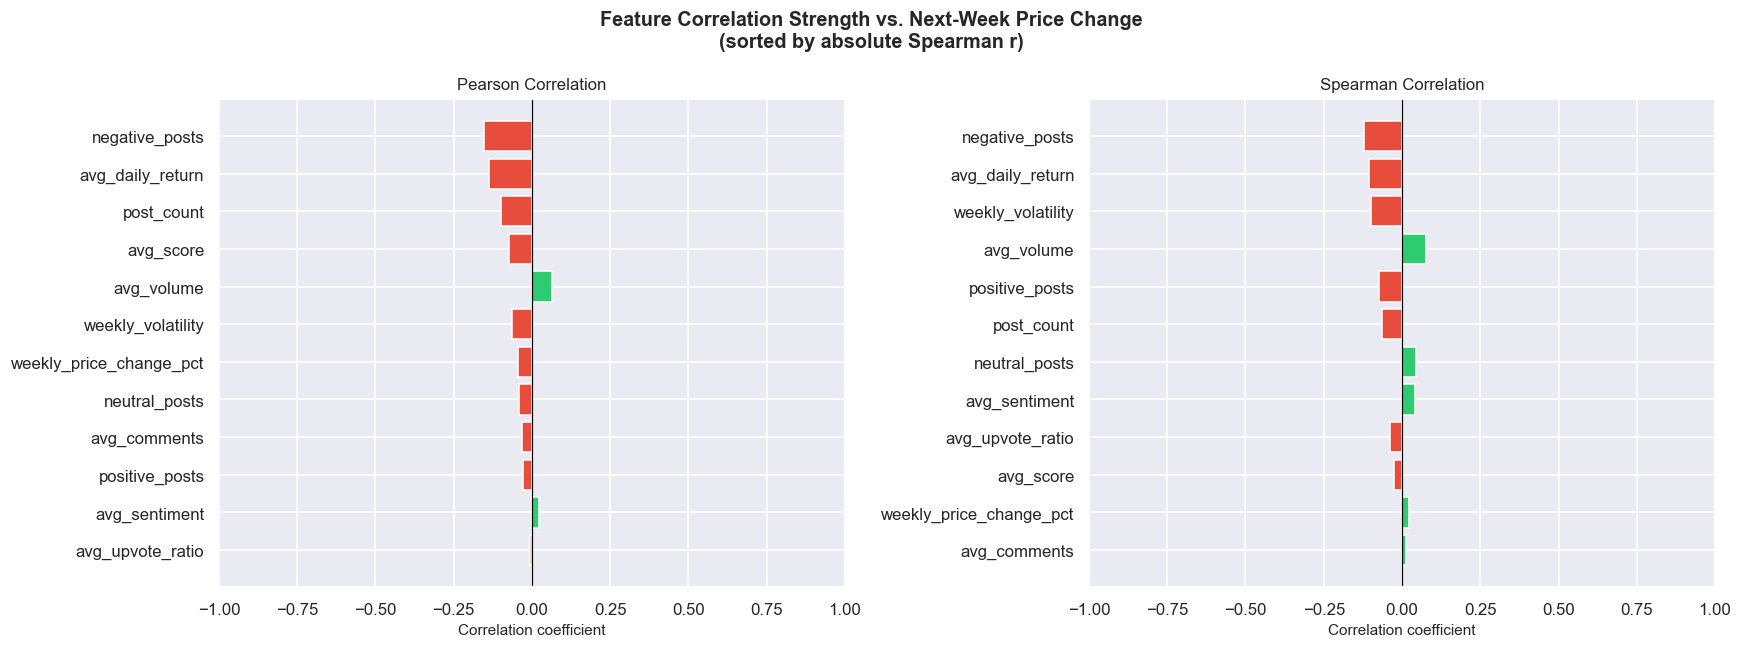

Saved → viz_lag_feature_importance.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Feature Correlation Strength vs. Next-Week Price Change\n(sorted by absolute Spearman r)", fontsize=13, fontweight="bold")

for ax, col, title in zip(
    axes,
    ["Pearson r", "Spearman r"],
    ["Pearson Correlation", "Spearman Correlation"]
):
    sorted_df   = lag_summary.sort_values(col, key=abs, ascending=True)
    bar_colors  = ["#2ecc71" if v >= 0 else "#e74c3c" for v in sorted_df[col]]
    ax.barh(sorted_df["Feature"], sorted_df[col], color=bar_colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Correlation coefficient", fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_xlim(-1, 1)

plt.tight_layout()
plt.savefig(f"{BASE}\\viz_lag_feature_importance.png", bbox_inches="tight")
plt.show()
print("Saved → viz_lag_feature_importance.png")

## Summary

| Section | Chart saved |
|---|---|
| Price trends | `viz_price_trends.png` |
| Volatility | `viz_volatility.png` |
| Moving averages | `viz_moving_averages.png` |
| Reddit vs price | `viz_reddit_vs_price.png` |
| Pearson heatmap | `viz_pearson_heatmap.png` |
| Spearman heatmap | `viz_spearman_heatmap.png` |
| Lag feature importance | `viz_lag_feature_importance.png` |

**Key takeaways:**
- Compare Pearson and Spearman values — where they diverge, the relationship is non-linear or driven by outliers
- Features with the highest absolute Spearman r vs `next_week_price_change_pct` are the strongest predictors of next-week moves
- Share all PNG charts and this notebook with Percival for the combined dashboard